## Assignment 4

This assignment asks you to use resources at hand to apply module 6 - Linear Regression to several sets of data.

## Learning Outcomes

- Exploratory analysis for regression
- Understand difference between linear and non-linear models
- Carry out OLS regression model
- Evaluate model


**Question 1**

* For each data set in Assignment4_linear_regression_data.xlsx:

- Create a scatter plot and visually decide if a linear model is appropriate (a matrix scatter plot will would be most efficient).

* If the relation is not linear, transform the data accordingly. 
 - Try logarithm, exponential, square root, square, etc., for Y and/or X until you see a linear relation.  You only need to report what is the transformation chosen, not all the attempts. 
 Note:  most of the time, you can guess visually. A systematic way is to create a matrix scatter plot of the different transformations.  A generic way we did not cover is to use a Box-Cox transformation. 
 
* Create an OLS model for the original and transformed data if required. 
 - Evaluate if the OLS assumptions are met: normality of errors centered around zero, equal variance, etc..., for the original data and transformed data if appropriate. 

 - Comment how the transformation impacted the different assumptions. (This should be done only by looking at the output diagnostic charts created by the software)
 - If datasets have outliers, remove the outliers and see the effect in the model (slope, intercept and R-square)


The output of the assignment should be: 

- OLS full report for the original and transformed data if appropriate (only two datasets should need transformation).

- A short comment on the validity of the linear assumptions for the original and transformed data set when appropriate (it should not need to be longer than a couple of sentences).

- An interpretation of the slope and intercept in relation to the original data, i.e. if the model is linear [intercept value] is the expected value when the independent variable is zero, etc.).  If the model is not linear, you need to transform the equation back to its original form.  

Check out the following if you need further guidance:
http://www.bzst.com/2009/09/interpreting-log-transformed-variables.html

https://stats.idre.ucla.edu/other/mult-pkg/faq/general/faqhow-do-i-interpret-a-regression-model-when-some-variables-are-log-transformed/

https://stats.idre.ucla.edu/sas/faq/how-can-i-interpret-log-transformed-variables-in-terms-of-percent-change-in-linear-regression/

https://stats.stackexchange.com/questions/266722/interpretation-of-linear-regression-results-where-dependent-variable-is-transfor

- If the dataset have outliers, determine if the outlier have leverage or not by comparing the OLS with and without the outlier.


In [1]:
# Import libraries.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as sm
from statsmodels.graphics.regressionplots import influence_plot

In [2]:
_data_file = 'Assignment4_linear_regresion_data.xlsx'

# class: linear_regression
#
# A class to facilitate linear regression modeling and analysis.

class linear_regression:
    
    
    def __init__(self, worksheet, x_column, y_column):
        
        # Constructor.
        
        self.worksheet = worksheet
        self.x_column = x_column
        self.y_column = y_column
        
        # Read in the worksheet from the Excel data file.
        
        self.df = pd.read_excel(_data_file, sheet_name=self.worksheet)
        
        # Use the seaborn charting style.
        
        plt.style.use('seaborn')
        sns.set(font_scale=1)

        
    def get_data_frame(self):
        
        return self.df
    
    
    def set_data_frame(self, new_df):
        
        self.df = new_df
    
    
    def print_data_frame(self):
        
        print(self.df)
        print(list(self.df.columns))

        
    def create_transformations(self):
        
        # Add square, log and square root transformations for X and Y to the Data Frame.
        
        self.df = self.df.assign(y_square = self.df[self.y_column]**2)
        self.df = self.df.assign(y_log = np.log(self.df[self.y_column]))
        self.df = self.df.assign(y_sqrt = np.sqrt(self.df[self.y_column]))

        self.df = self.df.assign(x_square = self.df[self.x_column]**2)
        self.df = self.df.assign(x_log = np.log(self.df[self.x_column]))
        self.df = self.df.assign(x_sqrt = np.sqrt(self.df[self.x_column]))
        
        
    def print_scatter_matrix(self, graph_title):
        
        # Display a scatter matrix of the Data Frame.
        
        pd.plotting.scatter_matrix(self.df, alpha=0.2, figsize=(15,15))
        plt.suptitle(graph_title)
        plt.show()
        
        
    def print_scatter(self, x_column, y_column, graph_title):
        
        # Display a scatter plot of the X and Y columns.
        
        plt.scatter(x = x_column, y = y_column, data = self.df, color='blue', s=5, edgecolor='none')
        plt.ylabel('Y')
        plt.xlabel('x')
        plt.show()

        sns.lmplot(x = x_column, y = y_column, data = self.df).set(title=graph_title)
 
        # Display the scatter plot.

        plt.show()
        
    
    def print_scatter_pred(self, x_column, y_column, y_pred, graph_title):
                
        # Display a scatter plot to include the X and Y observation data along with the
        # predictions for the Y dependent variable.
        
        plt.plot(self.df[x_column], self.df[y_column], 'o', label = 'Observations')
        plt.xlabel('x')
        plt.ylabel('y')

        # Plot the regression line.
        
        plt.plot(self.df[x_column], self.df[y_pred], 'r-', label='Regression line')

        # Plot the residuals (errors).
        
        plt.vlines(self.df[x_column], self.df[y_pred], self.df[y_column], linestyles='dashed', label = 'errors')
    
        # Add a legend and display the scatter plot.
        
        plt.legend()
        plt.show()

   
    def get_corr(self, x_column, y_column):
        
        print('Correlation: ', self.df[[x_column, y_column]].corr())
        
        
    def calculate_residuals(self, x_column, y_column, y_column_predicted, y_column_residual, regression_results):
        
        # Using the slope and intercept, calculate the predicted values of the dependent
        # variable, Y, along with the residuals (errors) between the observed Y value and
        # the predicted Y value for that X value.
        
        intercept, slope = regression_results.params
        
        self.df[y_column_predicted] = intercept + slope * self.df[x_column]
        
        # Create a new residual column in the Data Frame.
        
        self.df[y_column_residual] = self.df[y_column_predicted] - self.df[y_column]
        
    
    def plot_residual_histogram(self, residual_column, residual_title):
        
        # Plot the histogram of the residuals.

        residuals_hist = plt.hist(self.df[residual_column])

        # Add axes labels

        plt.xlabel(residual_title)
        plt.ylabel('Number')

        # Display the statistical summary of the residuals.

        print(self.df[residual_column].describe())

        
    def fit_model(self, x_column, y_column):
        
        # Fit the linear regression model based on the specified X and Y columns.

        return sm.ols(y_column + '~' + x_column, data = self.df).fit()

    
    def get_regression_parameters(self, regression_results):
        
        # Get and return the intercept and slope values.
        
        intercept, slope = regression_results.params
        
        return intercept, slope

    
    def visualize_residuals(self, regression_results):
        
        # Visualize the regression results in a residual influence diagram.
        
        fig, ax = plt.subplots(figsize=(15,6))
        fig = influence_plot(regression_results, ax=ax)


# <font color='Blue'>DATA SET 1</font>

In [3]:
# Create the Set 1 object and print out the Data Frame.

my_lr1 = linear_regression('Set 1', 'x', 'y')
my_lr1.get_data_frame().head()


,y,x
0,38.858144,7.266278
1,40.891148,7.985333
2,48.971648,9.387120
3,46.410124,9.382849
4,25.333391,5.240903


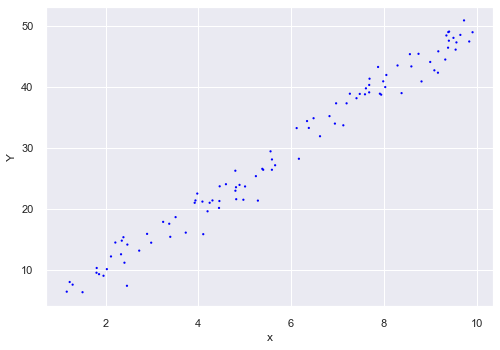

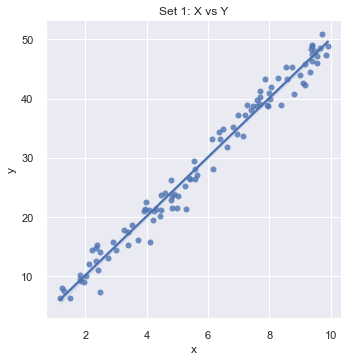

In [4]:
# Print the scatter matrix for the base X and Y variables

my_lr1.print_scatter('x', 'y', 'Set 1: X vs Y')


In [5]:
# Visually, it looks linear.  Get the correlation.

my_lr1.get_corr('x', 'y')

# There appears to be a strong correlation between x and y (.98).  No transformation needed.

Correlation:            x         y
x  1.000000  0.989468
y  0.989468  1.000000


In [6]:
# Validate the linear regression model by conducting an OLS fit.

results_set1 = my_lr1.fit_model('x', 'y')
results_set1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     4579.
Date:                Sun, 26 Mar 2023   Prob (F-statistic):           4.47e-84
Time:                        22:22:23   Log-Likelihood:                -206.03
No. Observations:                 100   AIC:                             416.1
Df Residuals:                      98   BIC:                             421.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2381      0.469      0.508      0.613      -0.693       1.169
x              4.9843      0.074     67.669      0.000       4.838       5.130
==============================================================================
Omnibus:                        4.971   Durbin-Watson:                   1.982
Prob(Omnibus):                  0.083   Jarque-Bera (JB):                4.783
Skew:                          -0.536   Prob(JB):                       0.0915
Kurtosis:                       2.988   Cond. No.                         15.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
# Extract the slope and intercept.

intercept, slope = my_lr1.get_regression_parameters(results_set1)

print ('Slope = ', slope, 'intercept = ', intercept)

# Identify the (x,y) point when x = 0.  Therefore, Y will just be the intercept.

print ('Therefore, a point on the graph (x,y) = (0,', intercept,')')


Slope =  4.9842585476668955 intercept =  0.23807024664959875
Therefore, a point on the graph (x,y) = (0, 0.23807024664959875 )


In [8]:
# Get points from the data where x is near 0.

df1 = my_lr1.get_data_frame()
df1[df1['x'] < 2].head(3)

,y,x
11,6.288716,1.504299
27,6.377976,1.163897
30,9.484998,1.805147


### Interpreting the OLS results.

The regression slope is positive (4.98) and the p-value is 0.  Therefore, there is a strong linear relationship.

The intercept point on the graph (x,y) = (0,.2381) looks like it would be correct based on visually reviewing points around the intercept of the original data.

The R-squared value is very high (.979) showing the regression model explains most of the data.


## Residuals

In [9]:
# Based on the slope and intercept, calculate the predictive Y results and the residuals.

my_lr1.calculate_residuals('x', 'y', 'y_pred', 'y_residual', results_set1)
my_lr1.get_data_frame().head()

,y,x,y_pred,y_residual
0,38.858144,7.266278,36.455079,-2.403065
1,40.891148,7.985333,40.039034,-0.852113
2,48.971648,9.387120,47.025903,-1.945745
3,46.410124,9.382849,47.004618,0.594494
4,25.333391,5.240903,26.360086,1.026695


count    1.000000e+02
mean     5.817569e-15
std      1.908727e+00
min     -3.763343e+00
25%     -1.472735e+00
50%     -2.630865e-01
75%      1.133296e+00
max      5.254912e+00
Name: y_residual, dtype: float64


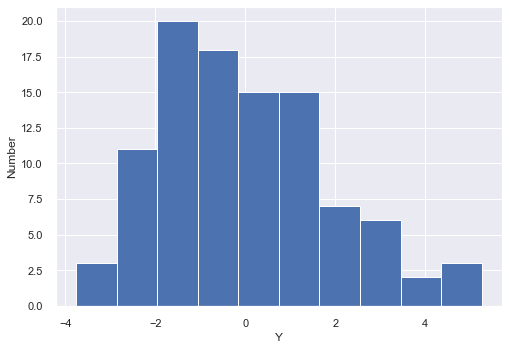

In [10]:
# Plot the residual distribution to look for a normal distribution.

my_lr1.plot_residual_histogram('y_residual', 'Y')


### Interpreting the Residuals (errors)

The residuals show a mostly Normal distribution centred around 0, slightly skewed to the right.
The mean and median of the residuals are close to 0 so that is good.
The prediction error range is from -3.76 to 5.25 which seems pretty low and is fairly balanced. 

Overall, the analysis of the residuals indicate that the regression line is good.

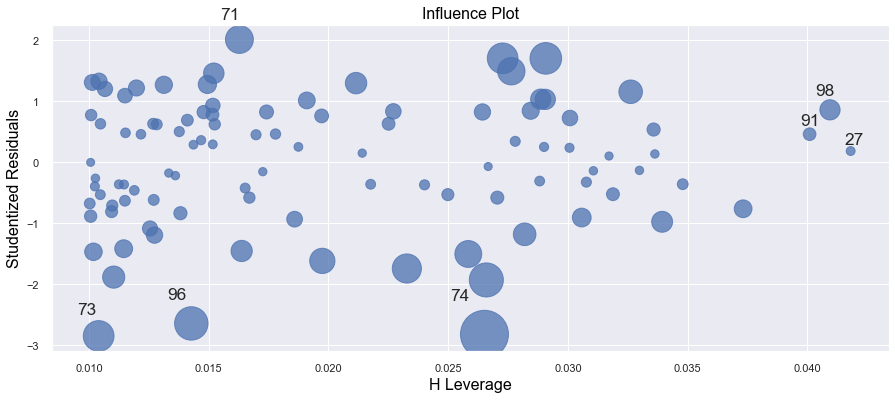

In [11]:
# Visualize the influence of the residuals.

my_lr1.visualize_residuals(results_set1)

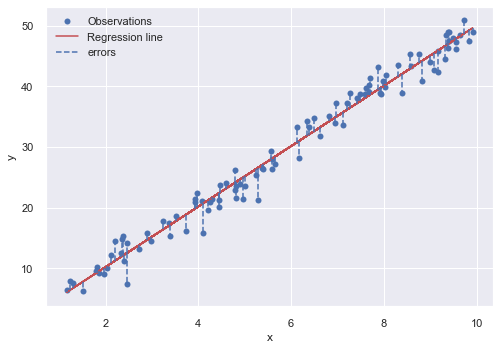

In [12]:
# From visualizing the residuals, we can see there is a point that is having a very large
# influence on the model.
#
# Visualize the regression line.

my_lr1.print_scatter_pred('x', 'y', 'y_pred', 'predicted vs actual')


In [13]:
# To see if there is any effect on the slope and intercept, remove a few of the points
# with the largest residual influence.

df1 = my_lr1.get_data_frame()

df1.drop([73,74,96], axis=0, inplace=True)
my_lr1.set_data_frame(df1)

# Re-fit the model.

results_set1 = my_lr1.fit_model('x', 'y')
results_set1.summary()



<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     5520.
Date:                Sun, 26 Mar 2023   Prob (F-statistic):           5.78e-86
Time:                        22:22:33   Log-Likelihood:                -188.83
No. Observations:                  97   AIC:                             381.7
Df Residuals:                      95   BIC:                             386.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6547      0.427      1.533      0.129      -0.193       1.503
x              4.9402      0.066     74.300      0.000       4.808       5.072
==============================================================================
Omnibus:                        4.836   Durbin-Watson:                   1.935
Prob(Omnibus):                  0.089   Jarque-Bera (JB):                2.735
Skew:                          -0.179   Prob(JB):                        0.255
Kurtosis:                       2.259   Cond. No.                         16.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Interpreting the OLS Results After Removing Influential Residuals

After removing the top three influential residuals, it didn't appear to significantly affect the values.

The R-Squared value is slightly better (.983 vs .979)
 
The slope and intercepts are essentially the same (4.9402 vs 4.98) and (.6547 vs .238)

count    9.700000e+01
mean    -6.931454e-15
std      1.703963e+00
min     -3.693996e+00
25%     -1.245560e+00
50%     -2.049791e-01
75%      1.212165e+00
max      3.751082e+00
Name: y_residual, dtype: float64


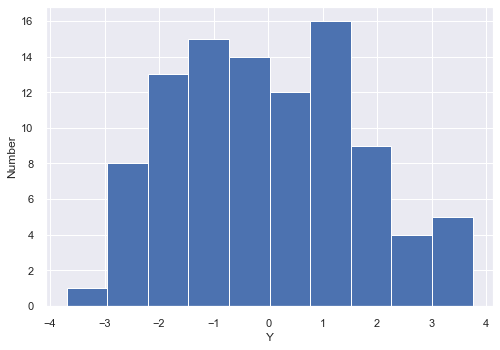

In [14]:
# Re-calculate the residuals.

my_lr1.calculate_residuals('x', 'y', 'y_pred', 'y_residual', results_set1)
my_lr1.plot_residual_histogram('y_residual', 'Y')


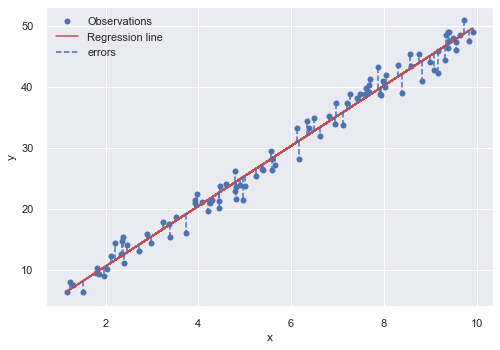

In [15]:
my_lr1.print_scatter_pred('x', 'y', 'y_pred', 'predicted vs actual')


### Interpreting the Residuals (errors) After Removing the Residuals with the Most Influence

The residuals show a mostly Normal distribution centred around 0.
The mean and median of the residuals are close to 0 so that is good.
The prediction error range is from -3.69 to 3.75 which is pretty low and well balanced. 

Overall, the analysis of the residuals, without the most influential points, indicate that the regression line is still good and comparable to the original.

### Summary

The OLS regression line fits very well and removing the influential residuals has no significant impact on the data.

# <font color='Blue'>DATA SET 2</font>

In [16]:
# Create the Set 2 object and print out the Data Frame.

my_lr2 = linear_regression('Set 2', 'x', 'y')
my_lr2.get_data_frame().head()


,y,x
0,28.045621,4.299210
1,39.148284,4.528143
2,17.361044,3.284988
3,18.413561,5.709732
4,7.857464,3.242708


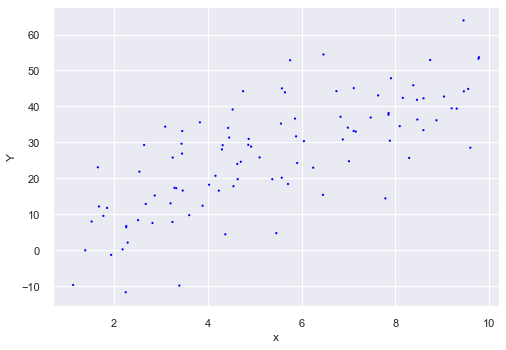

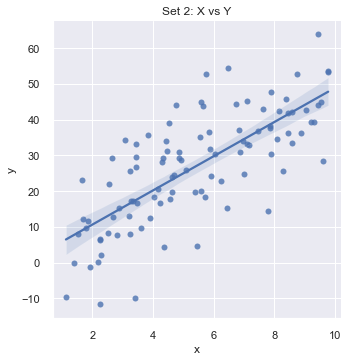

In [17]:
# Print the scatter matrix for the base X and Y variables

my_lr2.print_scatter('x', 'y', 'Set 2: X vs Y')


In [18]:
# Visually, it looks fairly linear.  Get the correlation.

my_lr2.get_corr('x', 'y')


Correlation:            x         y
x  1.000000  0.745168
y  0.745168  1.000000


In [19]:
# There appears to be a fairly good correlation between x and y (.745).  No transformation needed.


In [20]:
# Validate the linear regression model by conducting an OLS fit.

results_set2 = my_lr2.fit_model('x', 'y')
results_set2.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.551
Method:                 Least Squares   F-statistic:                     122.4
Date:                Sun, 26 Mar 2023   Prob (F-statistic):           6.11e-19
Time:                        22:29:02   Log-Likelihood:                -375.73
No. Observations:                 100   AIC:                             755.5
Df Residuals:                      98   BIC:                             760.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.0956      2.547      0.430      0.668      -3.958       6.149
x              4.7774      0.432     11.062      0.000       3.920       5.634
==============================================================================
Omnibus:                        0.254   Durbin-Watson:                   2.043
Prob(Omnibus):                  0.881   Jarque-Bera (JB):                0.079
Skew:                          -0.065   Prob(JB):                        0.961
Kurtosis:                       3.045   Cond. No.                         14.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [21]:
# Extract the slope and intercept.

intercept, slope = my_lr2.get_regression_parameters(results_set2)

print ('Slope = ', slope, 'intercept = ', intercept)

# Identify the (x,y) point when x = 0.  Therefore, Y will just be the intercept.

print ('Therefore, a point on the graph (x,y) = (0,', intercept,')')


Slope =  4.7773536886574695 intercept =  1.095552065545124
Therefore, a point on the graph (x,y) = (0, 1.095552065545124 )


In [22]:
# Get points from the data where x is near 0.

df2 = my_lr1.get_data_frame()
df2[df2['x'] < 10].head(3)

,y,x,y_pred,y_residual
0,38.858144,7.266278,36.551235,-2.306910
1,40.891148,7.985333,40.103481,-0.787667
2,48.971648,9.387120,47.028534,-1.943114


### Interpreting the OLS results.

The regression slope is positive (4.77) and the p-value is 0.  Therefore, there is a good linear relationship.

The intercept point on the graph (x,y) = (0,1.095) looks like it would be correct based on visually reviewing points around the intercept of the original data.

The R-squared value is ok (.555) showing the regression model explains more than half of the data.

## Residuals

In [23]:
# Based on the slope and intercept, calculate the predictive Y results and the residuals.

my_lr2.calculate_residuals('x', 'y', 'y_pred', 'y_residual', results_set2)
my_lr2.get_data_frame().head()


,y,x,y_pred,y_residual
0,28.045621,4.299210,21.634397,-6.411223
1,39.148284,4.528143,22.728095,-16.420189
2,17.361044,3.284988,16.789103,-0.571941
3,18.413561,5.709732,28.372961,9.959400
4,7.857464,3.242708,16.587117,8.729653


count    1.000000e+02
mean    -6.963319e-15
std      1.041688e+01
min     -2.427189e+01
25%     -6.825796e+00
50%      3.255999e-01
75%      6.370633e+00
max      2.713100e+01
Name: y_residual, dtype: float64


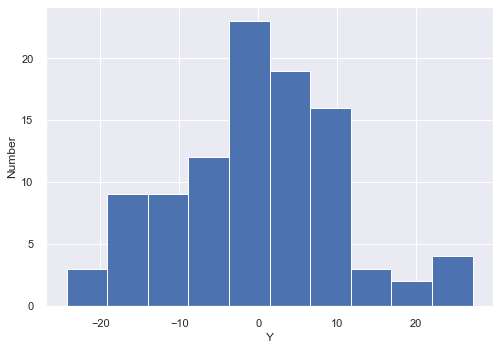

In [24]:
# Plot the residual distribution to look for a normal distribution.

my_lr2.plot_residual_histogram('y_residual', 'Y')


### Interpreting the Residuals (errors)

The residuals show a mostly Normal distribution centred around 0.
The mean and median of the residuals are close to 0 so that is good.
The prediction error range is from -24.3 to 27.1 which seems ok but is equally spread. 

Overall, the analysis of the residuals indicate that the regression line is good.


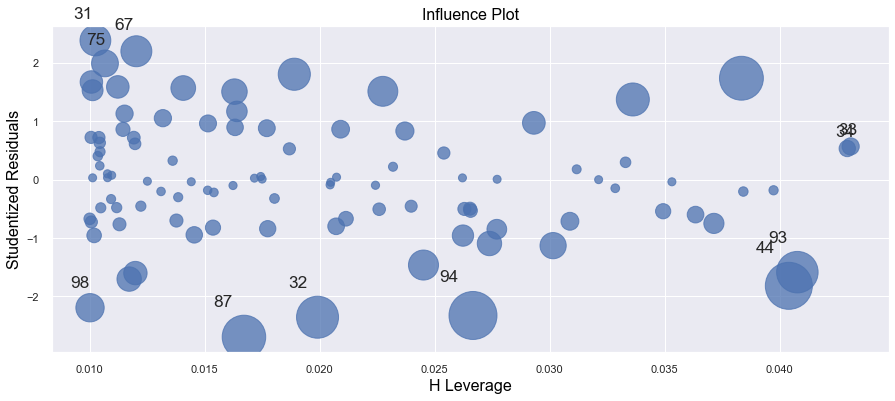

In [25]:
# Visualize the influence of the residuals.

my_lr2.visualize_residuals(results_set2)

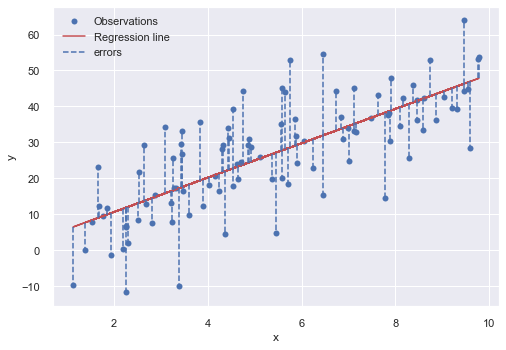

In [26]:
# From visualizing the residuals, we can see there are a few points that are having a very large
# influence on the model.
#
# Visualize the regression line.

my_lr2.print_scatter_pred('x', 'y', 'y_pred', 'predicted vs actual')



In [27]:
# To see if there is any effect on the slope and intercept, remove a few of the points
# with the largest residual influence.

df2 = my_lr2.get_data_frame()

df2.drop([32,44,87,93,94], axis=0, inplace=True)
my_lr2.set_data_frame(df2)

# Re-fit the model.

results_set2 = my_lr2.fit_model('x', 'y')
results_set2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.586
Model:                            OLS   Adj. R-squared:                  0.582
Method:                 Least Squares   F-statistic:                     131.7
Date:                Sun, 26 Mar 2023   Prob (F-statistic):           1.63e-19
Time:                        22:32:15   Log-Likelihood:                -346.27
No. Observations:                  95   AIC:                             696.5
Df Residuals:                      93   BIC:                             701.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.8898      2.394      1.207      0.230      -1.864       7.644
x              4.6578      0.406     11.477      0.000       3.852       5.464
==============================================================================
Omnibus:                        1.357   Durbin-Watson:                   2.015
Prob(Omnibus):                  0.507   Jarque-Bera (JB):                1.320
Skew:                           0.278   Prob(JB):                        0.517
Kurtosis:                       2.847   Cond. No.                         15.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Interpreting the OLS Results After Removing Influential Residuals

After removing the top three influential residuals, it didn't appear to significantly affect the values.

The R-Squared value is slightly better (.586 vs .555)
 
The slope and intercepts are essentially the same (4.66 vs 4.77) and (2.89 vs 1.09)


count    9.500000e+01
mean     8.227337e-16
std      9.311489e+00
min     -2.316547e+01
25%     -6.335461e+00
50%      1.129370e+00
75%      6.267859e+00
max      2.356896e+01
Name: y_residual, dtype: float64


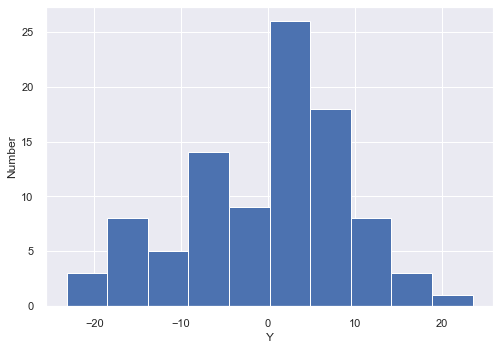

In [28]:
# Re-calculate the residuals.

my_lr2.calculate_residuals('x', 'y', 'y_pred', 'y_residual', results_set2)
my_lr2.plot_residual_histogram('y_residual', 'Y')

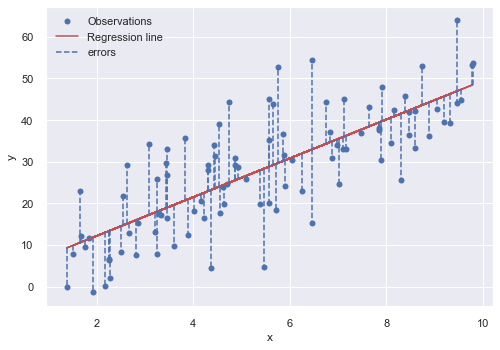

In [29]:
my_lr2.print_scatter_pred('x', 'y', 'y_pred', 'predicted vs actual')


### Interpreting the Residuals (errors) After Removing the Residuals with the Most Influence

The residuals show a mostly Normal distribution centred around 0.
The mean and median of the residuals are close to 0 so that is good.
The prediction error range is from -23.1 to 23.5 which is ok but evenly distanced. 

Overall, the analysis of the residuals, without the most influential points, indicate that the regression line is still good and comparable to the original.


### Summary

The OLS regression line fits pretty well and removing some of the influential residuals has no significant impact on the data.

# <font color='Blue'>DATA SET 3</font>

In [30]:
# Create the Set 3 object and print out the Data Frame.

my_lr3 = linear_regression('Set 3', 'x', 'Y')
my_lr3.get_data_frame().head()


,Y,x
0,6428.915770,9.517
1,2640.000728,5.113
2,12858.599267,9.773
3,5491.450053,8.428
4,2838.820108,5.752


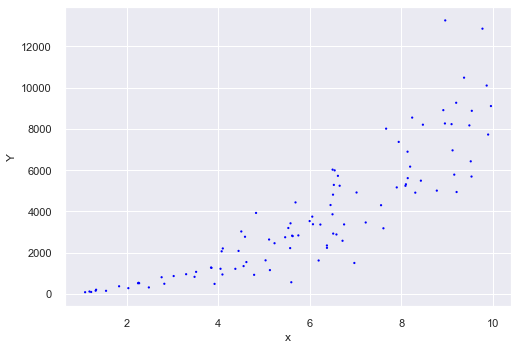

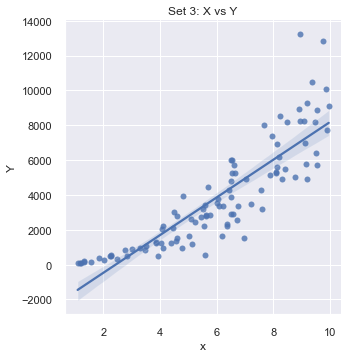

In [31]:
# Print the scatter matrix for the base X and Y variables

my_lr3.print_scatter('x', 'Y', 'Set 3: X vs Y')


In [33]:
# Visually, it does ** NOT** look linear.  Get the correlation.

my_lr3.get_corr('x', 'Y')

# Interesting - it has a very high correlation, .87, but it's not linear.  Perhaps because
# a large number of the points are close to the regression line.


Correlation:            x         Y
x  1.000000  0.869031
Y  0.869031  1.000000


In [34]:
# Examine the linear regression model by conducting an OLS fit.

results_set3 = my_lr3.fit_model('x', 'Y')
results_set3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.755
Model:                            OLS   Adj. R-squared:                  0.753
Method:                 Least Squares   F-statistic:                     302.4
Date:                Sun, 26 Mar 2023   Prob (F-statistic):           1.04e-31
Time:                        22:37:06   Log-Likelihood:                -873.07
No. Observations:                 100   AIC:                             1750.
Df Residuals:                      98   BIC:                             1755.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -2636.1748    402.741     -6.546      0.000   -3435.400   -1836.949
x           1081.8266     62.216     17.388      0.000     958.361    1205.292
==============================================================================
Omnibus:                       21.170   Durbin-Watson:                   2.159
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               37.896
Skew:                           0.863   Prob(JB):                     5.90e-09
Kurtosis:                       5.474   Cond. No.                         17.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [35]:
# Verify the slope and intercept

intercept, slope = my_lr3.get_regression_parameters(results_set3)

print ('Slope = ', slope, 'intercept = ', intercept)

# Identify the (x,y) point when x = 0.  Therefore, Y will just be the intercept.

print ('Therefore, a point on the graph (x,y) = (0,', intercept,')')


Slope =  1081.8265912024272 intercept =  -2636.174839306118
Therefore, a point on the graph (x,y) = (0, -2636.174839306118 )


In [36]:
# Get points from the data where x is near 0.

df3 = my_lr3.get_data_frame()
df3[df3['x'] < 2].head(3)

,Y,x
10,97.070321,1.227
57,119.506472,1.190
62,85.816012,1.095


### Interpreting the OLS results.

The regression slope is extreme (1081.83) and the intercept point on the graph (x,y) = (0,-2636.17) does not look like it would be correct (via a linear regression model) based on visually reviewing points around the intercept of the original data (e.g., the point (1.095, 85.816)).

The R-squared value is still quite good (.755) showing the regression model explains most of the data.

## Residuals


In [38]:
# Based on the slope and intercept, calculate the predictive Y results and the residuals.

my_lr3.calculate_residuals('x', 'Y', 'y_pred', 'y_residual', results_set3)
my_lr3.get_data_frame().head()


,Y,x,y_pred,y_residual
0,6428.915770,9.517,7659.568829,1230.653059
1,2640.000728,5.113,2895.204522,255.203793
2,12858.599267,9.773,7936.516437,-4922.082830
3,5491.450053,8.428,6481.459671,990.009618
4,2838.820108,5.752,3586.491713,747.671605


count    1.000000e+02
mean    -1.753051e-12
std      1.505310e+03
min     -6.202119e+03
25%     -9.320867e+02
50%      1.251402e+02
75%      8.943890e+02
max      3.406664e+03
Name: y_residual, dtype: float64


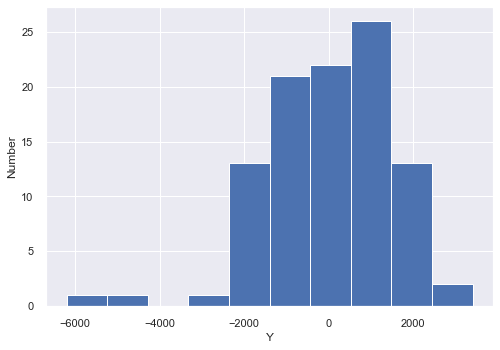

In [39]:
# Plot the residual distribution to look for a normal distribution.

my_lr3.plot_residual_histogram('y_residual', 'Y')


### Interpreting the Residuals (errors)

The residuals show a mostly Normal distribution centred around 0, except it is widely skewed to the left.
The mean of the residuals is close to 0 but the median of the residuals is not so that is not good.
The prediction error range is from -6202 to 3406 which is very wide and not evenly distributed. 

Overall, the analysis of the residuals indicate that the regression line is not good and should be transformed.

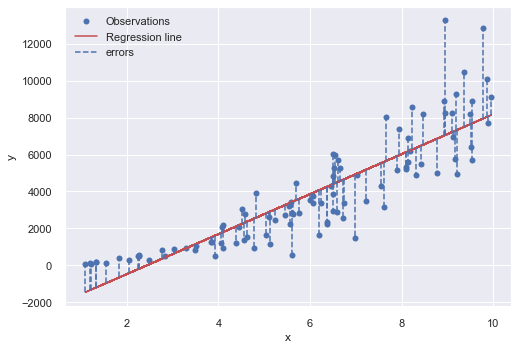

In [40]:
# Visualize the predicted line and the residuals.

my_lr3.print_scatter_pred('x', 'Y', 'y_pred', 'predicted vs actual')


## Transformations

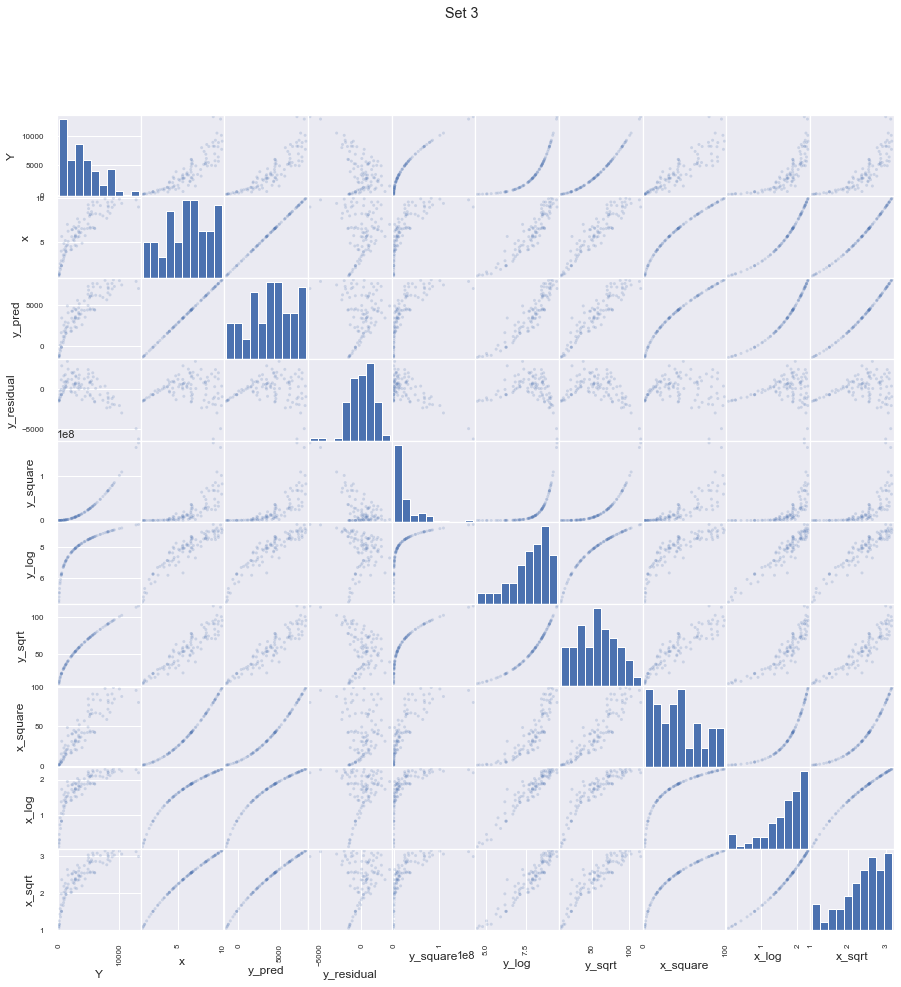

In [41]:
# Create the transformations (square, square root, log, exponential).

my_lr3.create_transformations()
my_lr3.print_scatter_matrix('Set 3')

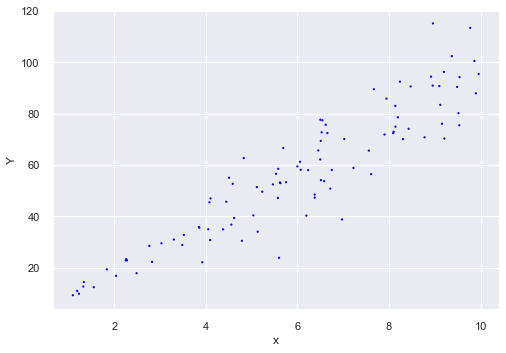

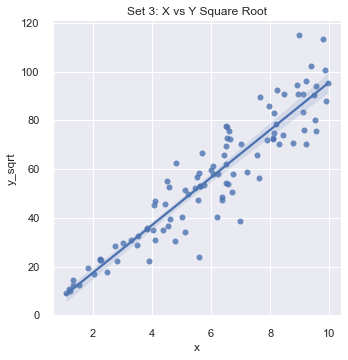

In [42]:
# Visually, the X and Y Square Root Transformation seems to be the best fit.
# Let's plot it to get a look in closer detail.

my_lr3.print_scatter('x', 'y_sqrt', 'Set 3: X vs Y Square Root')


In [43]:
# Validate the linear regression model by conducting an OLS fit.

results_transform_set3 = my_lr3.fit_model('x', 'y_sqrt')
results_transform_set3.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 y_sqrt   R-squared:                       0.857
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     588.0
Date:                Sun, 26 Mar 2023   Prob (F-statistic):           3.37e-43
Time:                        22:41:46   Log-Likelihood:                -369.26
No. Observations:                 100   AIC:                             742.5
Df Residuals:                      98   BIC:                             747.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.2001      2.612     -0.842      0.402      -7.384       2.984
x              9.7861      0.404     24.249      0.000       8.985      10.587
==============================================================================
Omnibus:                        2.926   Durbin-Watson:                   1.892
Prob(Omnibus):                  0.232   Jarque-Bera (JB):                2.648
Skew:                          -0.150   Prob(JB):                        0.266
Kurtosis:                       3.739   Cond. No.                         17.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [44]:
# Verify the slope and intercept

intercept, slope = my_lr3.get_regression_parameters(results_transform_set3)
print ('Slope = ', slope, 'intercept = ', intercept)

# Identify the (x,y) point when x = 0.  Therefore, Y will just be the intercept.

print ('Therefore, a point on the graph (x,y) = (0,', intercept,')')


Slope =  9.786056475824669 intercept =  -2.200087854659242
Therefore, a point on the graph (x,y) = (0, -2.200087854659242 )


In [45]:
# Get points from the data where x is near 0.

df3 = my_lr3.get_data_frame()
df3[df3['x'] < 2].head(3)

,Y,x,y_pred,y_residual,y_square,y_log,y_sqrt,x_square,x_log,x_sqrt
10,97.070321,1.227,-1308.773612,-1405.843933,9422.647203,4.575436,9.852427,1.505529,0.204572,1.107700
57,119.506472,1.190,-1348.801196,-1468.307667,14281.796733,4.783371,10.931902,1.416100,0.173953,1.090871
62,85.816012,1.095,-1451.574722,-1537.390734,7364.387872,4.452206,9.263693,1.199025,0.090754,1.046422


### Interpreting the OLS results.

The regression slope of the transformation is positive (9.78) and the p-value is 0.  Therefore, there is a strong linear relationship.

The intercept point on the graph (x,y) = (0,-2.20) looks like it would be correct based on visually reviewing points around the intercept of the transformed data.

The slope and intercept points of the transformed data are better values compared to the original set.

The R-squared value of the transformed data is very high (.857) showing the regression model explains most of the data.



## Transformation Residuals


In [46]:
# Based on the slope and intercept, calculate the predictive Y results and the residuals.

my_lr3.calculate_residuals('x', 'y_sqrt', 'y_sqrt_pred', 'y_sqrt_residual', results_transform_set3)
my_lr3.get_data_frame().head()


,Y,x,y_pred,y_residual,y_square,y_log,y_sqrt,x_square,x_log,x_sqrt,y_sqrt_pred,y_sqrt_residual
0,6428.915770,9.517,7659.568829,1230.653059,4.133096e+07,8.768561,80.180520,90.573289,2.253080,3.084964,90.933812,10.753292
1,2640.000728,5.113,2895.204522,255.203793,6.969604e+06,7.878534,51.380937,26.142769,1.631786,2.261194,47.836019,-3.544918
2,12858.599267,9.773,7936.516437,-4922.082830,1.653436e+08,9.461768,113.395764,95.511529,2.279623,3.126180,93.439042,-19.956722
3,5491.450053,8.428,6481.459671,990.009618,3.015602e+07,8.610948,74.104319,71.031184,2.131559,2.903102,80.276796,6.172477
4,2838.820108,5.752,3586.491713,747.671605,8.058900e+06,7.951144,53.280579,33.085504,1.749548,2.398333,54.089309,0.808730


count    1.000000e+02
mean     4.511946e-15
std      9.764075e+00
min     -2.966523e+01
25%     -4.891936e+00
50%     -5.482943e-01
75%      5.731302e+00
max      2.873840e+01
Name: y_sqrt_residual, dtype: float64


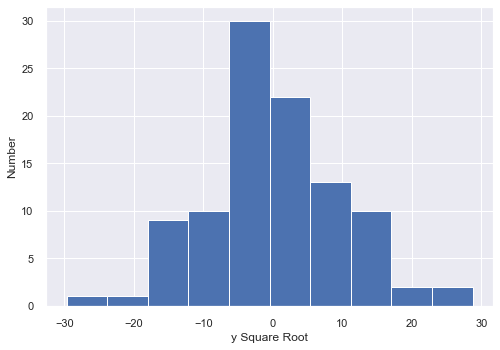

In [47]:
# Plot the residual distribution to look for a normal distribution.

my_lr3.plot_residual_histogram('y_sqrt_residual', 'y Square Root')


### Interpreting the Transformation Residuals (errors)

The residuals show a mostly Normal distribution centred around 0.
The mean and median of the residuals are close to 0 so that is good.
The prediction error range is from -29.7 to 28.7 which seems pretty low and evenly spread. 

Overall, the analysis of the residuals indicate that the transformed regression line is good.

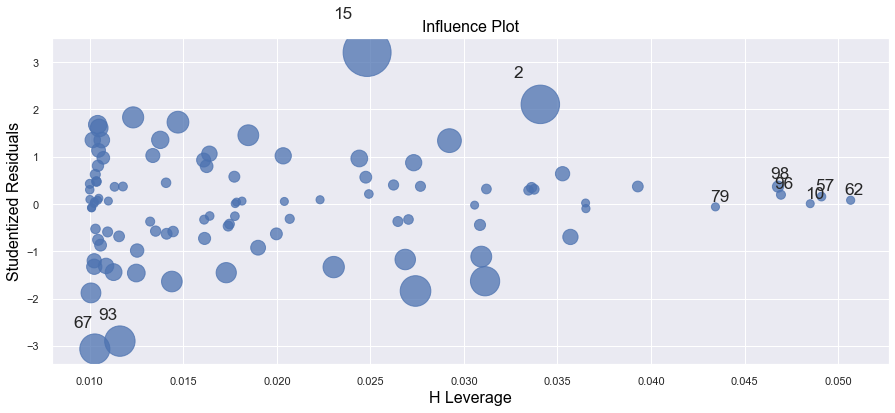

In [48]:
# Visualize the influence of the residuals.

my_lr3.visualize_residuals(results_transform_set3)


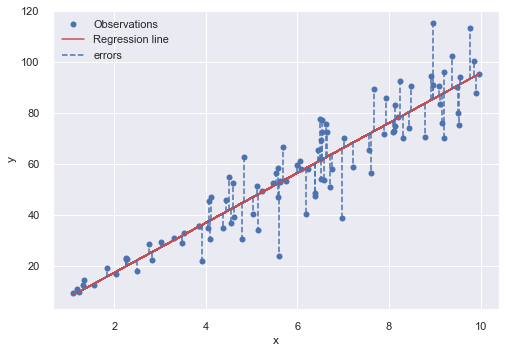

In [49]:
# From visualizing the residuals, we can see there are a few points that are having a very large
# influence on the model.
#
# Visualize the regression line.

my_lr3.print_scatter_pred('x', 'y_sqrt', 'y_sqrt_pred', 'predicted vs actual')


In [50]:
# To see if there is any effect on the slope and intercept, remove a few of the points
# with the largest residual influence.

df3 = my_lr3.get_data_frame()

df3.drop([2, 15, 67, 93], axis=0, inplace=True)
my_lr3.set_data_frame(df3)

# Re-fit the model.

results_transform_set3 = my_lr3.fit_model('x', 'y_sqrt')
results_transform_set3.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 y_sqrt   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     737.9
Date:                Sun, 26 Mar 2023   Prob (F-statistic):           2.72e-46
Time:                        22:44:14   Log-Likelihood:                -338.92
No. Observations:                  96   AIC:                             681.8
Df Residuals:                      94   BIC:                             687.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.5911      2.245     -0.263      0.793      -5.049       3.866
x              9.5257      0.351     27.164      0.000       8.829      10.222
==============================================================================
Omnibus:                        0.712   Durbin-Watson:                   1.903
Prob(Omnibus):                  0.700   Jarque-Bera (JB):                0.772
Skew:                          -0.009   Prob(JB):                        0.680
Kurtosis:                       2.561   Cond. No.                         17.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Interpreting the OLS Results After Removing Influential Residuals

After removing the top four influential residuals, it didn't appear to significantly affect the values.

The R-Squared value is slightly better (.887 vs .857)
 
The slope and intercepts are essentially the same (9.5257 vs 9.7861) and (-0.5911 vs -2.2001)


count    9.600000e+01
mean    -1.132427e-14
std      8.303819e+00
min     -1.728153e+01
25%     -4.680024e+00
50%     -2.257817e-01
75%      5.603368e+00
max      1.813231e+01
Name: y_sqrt_residual, dtype: float64


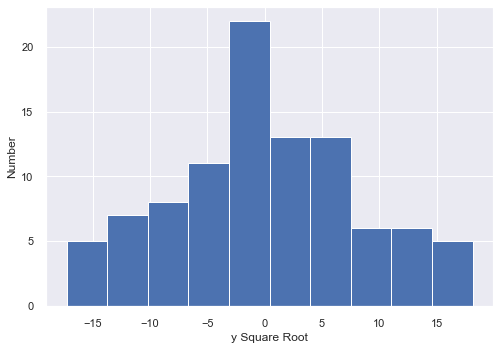

In [52]:
# Re-calculate the residuals.

my_lr3.calculate_residuals('x', 'y_sqrt', 'y_sqrt_pred', 'y_sqrt_residual', results_transform_set3)
my_lr3.plot_residual_histogram('y_sqrt_residual', 'y Square Root')


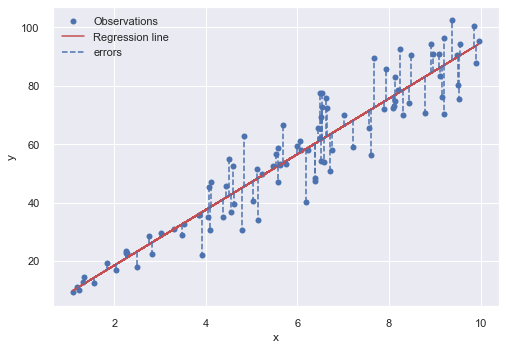

In [53]:
my_lr3.print_scatter_pred('x', 'y_sqrt', 'y_sqrt_pred', 'predicted vs actual')


### Interpreting the Residuals (errors) After Removing the Residuals with the Most Influence

The residuals show a mostly Normal distribution centred around 0.
The mean and the median of the residuals are close to 0 so that is good.
The prediction error range is from -17.28 to 18.13 which is better than the transformation before the influential residuals were removed. 

Overall, the analysis of the residuals, without the most influential points, indicate that the regression line is still good and comparable to the original.

### Equation

The transformed equation that creates a linear regression line:  sqrt(y) = (9.5257 * x) -0.5911
Therefore, transforming that back is: y = [(9.5257 * x) - 0.5911)]^2

### Summary

The OLS regression line of the original data does not fit.  It therefore had to be transformed to get a linear regression model that would fit.  The transformation used was the square root of Y.  After this transformation, and the removal of just a few influential residuals, the linear regression model fit quite well.

# <font color='Blue'>DATA SET 4</font>

In [54]:
# Create the Set 4 object and print out the Data Frame.

my_lr4 = linear_regression('Set 4', 'x', 'Y')
my_lr4.get_data_frame().head()


,Y,x
0,1.887192e+05,5.9947
1,7.107264e+03,3.9492
2,3.729064e+06,9.6353
3,5.691779e+02,0.4943
4,3.022130e+06,9.0811


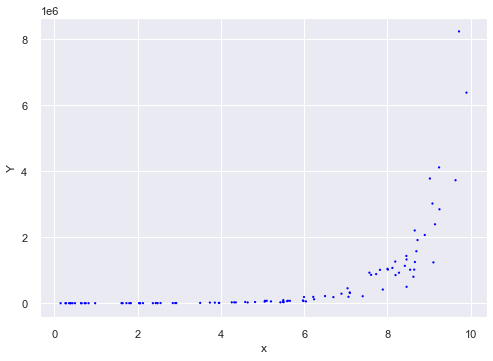

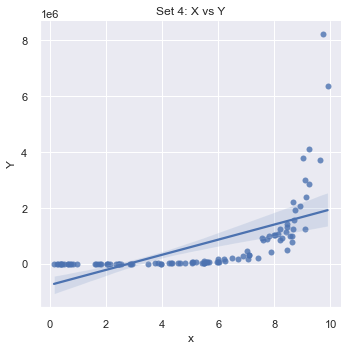

In [55]:
# Print the scatter matrix for the base X and Y variables

my_lr4.print_scatter('x', 'Y', 'Set 4: X vs Y')


In [56]:
# Visually, it does ** NOT** look linear.  Get the correlation.

my_lr4.get_corr('x', 'Y')

# The correlation is .616.

Correlation:            x         Y
x  1.000000  0.616155
Y  0.616155  1.000000


In [57]:
# Validate the linear regression model by conducting an OLS fit.

results_set4 = my_lr4.fit_model('x', 'Y')
results_set4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.373
Method:                 Least Squares   F-statistic:                     59.97
Date:                Sun, 26 Mar 2023   Prob (F-statistic):           8.87e-12
Time:                        22:47:09   Log-Likelihood:                -1526.2
No. Observations:                 100   AIC:                             3056.
Df Residuals:                      98   BIC:                             3062.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7.535e+05    2.1e+05     -3.585      0.001   -1.17e+06   -3.36e+05
x           2.707e+05   3.49e+04      7.744      0.000    2.01e+05     3.4e+05
==============================================================================
Omnibus:                      102.143   Durbin-Watson:                   2.077
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1253.666
Skew:                           3.381   Prob(JB):                    5.89e-273
Kurtosis:                      18.973   Cond. No.                         12.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [58]:
# Extract the slope and intercept.

intercept, slope = my_lr4.get_regression_parameters(results_set4)

print ('Slope = ', slope, 'intercept = ', intercept)

# Identify the (x,y) point when x = 0.  Therefore, Y will just be the intercept.

print ('Therefore, a point on the graph (x,y) = (0,', intercept,')')

Slope =  270653.4900620666 intercept =  -753498.6681300632
Therefore, a point on the graph (x,y) = (0, -753498.6681300632 )


In [59]:
# Get points from the data where x is near 0.

df4 = my_lr4.get_data_frame()
df4[df4['x'] < 1].head(3)

,Y,x
3,569.177911,0.4943
12,909.079523,0.8204
13,667.633039,0.7530


### Interpreting the OLS results.

The regression slope is extreme (270,653) and the intercept point on the graph (x,y) = (0,-753,498) does not look like it would be correct (via a linear regression model) based on visually reviewing points around the intercept of the original data (e.g., the point (0.4943, 569.178)).

The R-squared value is not good (.380) showing the regression model explains less than 40% of the data.


## Residuals

In [60]:
# Based on the slope and intercept, calculate the predictive Y results and the residuals.

my_lr4.calculate_residuals('x', 'Y', 'y_pred', 'y_residual', results_set4)
my_lr4.get_data_frame().head()


,Y,x,y_pred,y_residual
0,1.887192e+05,5.9947,8.689878e+05,6.802686e+05
1,7.107264e+03,3.9492,3.153661e+05,3.082588e+05
2,3.729064e+06,9.6353,1.854329e+06,-1.874735e+06
3,5.691779e+02,0.4943,-6.197146e+05,-6.202838e+05
4,3.022130e+06,9.0811,1.704333e+06,-1.317797e+06


count    1.000000e+02
mean    -2.956949e-10
std      1.033103e+06
min     -6.364011e+06
25%     -3.134527e+05
50%      3.081833e+05
75%      6.187548e+05
max      1.039076e+06
Name: y_residual, dtype: float64


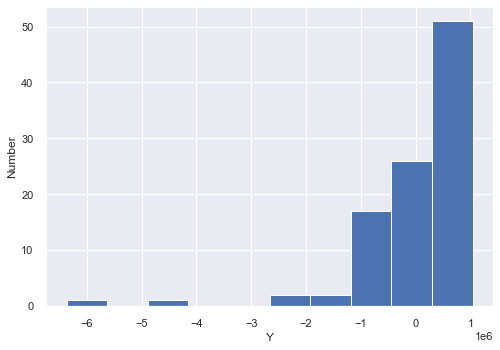

In [61]:
# Plot the residual distribution to look for a normal distribution.

my_lr4.plot_residual_histogram('y_residual', 'Y')


### Interpreting the Residuals (errors)

The residuals show a left-skewed distribution.
The mean is close to 0 but the median is not.
The prediction error range is from -6364011 to 1039076 which is quite vast. 

Overall, the analysis of the residuals indicate that the regression line is not good.


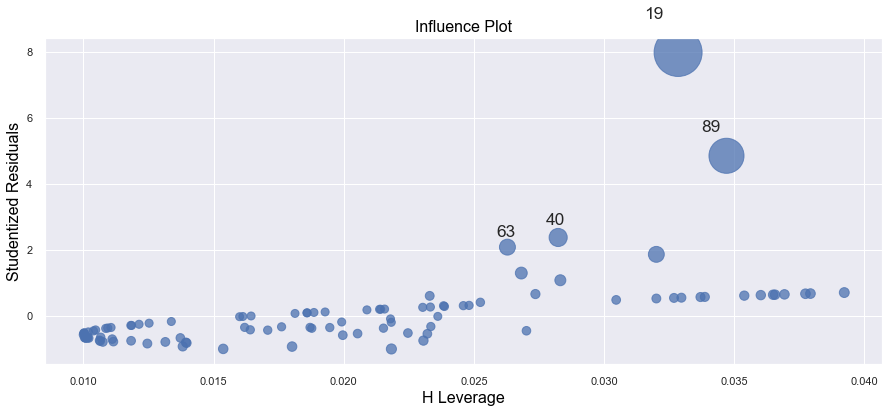

In [62]:
# Visualize the influence of the residuals.

my_lr4.visualize_residuals(results_set4)

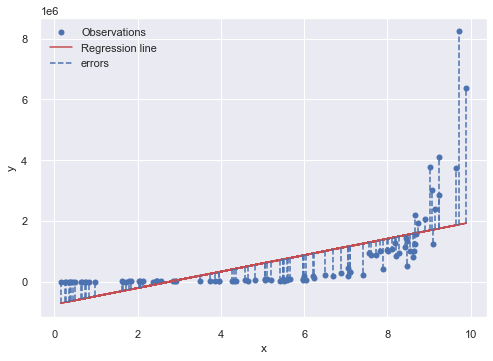

In [63]:
# From visualizing the residuals, we can see there is a point that is having a very large
# influence on the model.
#
# Visualize the regression line.

my_lr4.print_scatter_pred('x', 'Y', 'y_pred', 'predicted vs actual')

## Transformations

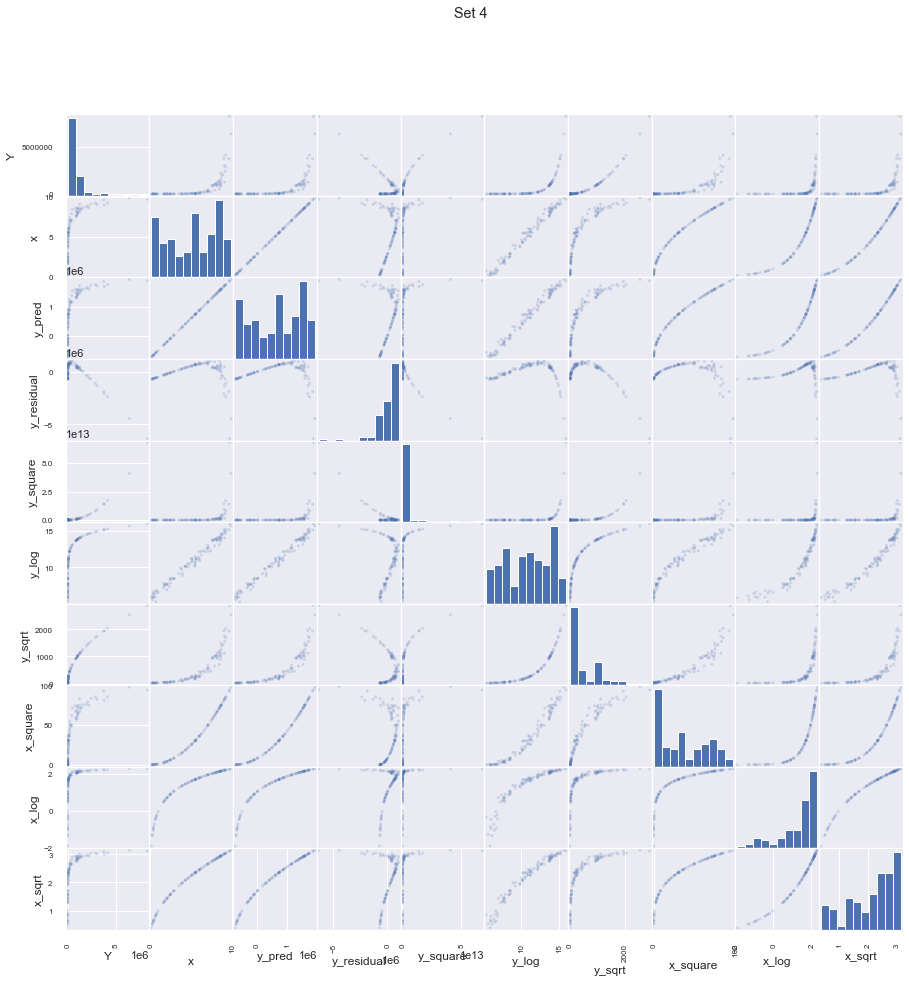

In [64]:
# Create the transformations (square, square root, log, exponential).

my_lr4.create_transformations()
my_lr4.print_scatter_matrix('Set 4')

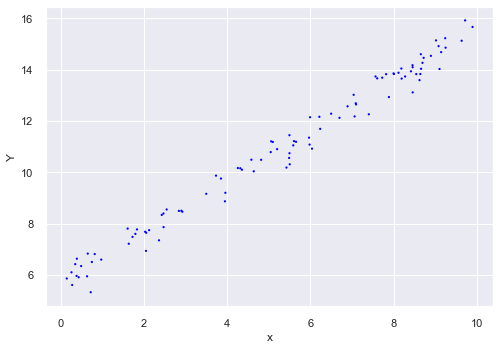

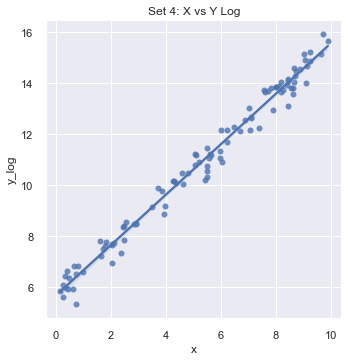

In [65]:
# Visually, the X and Y Log Transformation seems to be the best fit.
# Let's plot it to get a look in closer detail.

my_lr4.print_scatter('x', 'y_log', 'Set 4: X vs Y Log')


In [66]:
# Validate the linear regression model by conducting an OLS fit.

results_transform_set4 = my_lr4.fit_model('x', 'y_log')
results_transform_set4.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  y_log   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     5765.
Date:                Sun, 26 Mar 2023   Prob (F-statistic):           6.91e-89
Time:                        22:50:16   Log-Likelihood:                -46.034
No. Observations:                 100   AIC:                             96.07
Df Residuals:                      98   BIC:                             101.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.6647      0.078     72.264      0.000       5.509       5.820
x              0.9898      0.013     75.930      0.000       0.964       1.016
==============================================================================
Omnibus:                        7.020   Durbin-Watson:                   2.151
Prob(Omnibus):                  0.030   Jarque-Bera (JB):                7.256
Skew:                          -0.657   Prob(JB):                       0.0266
Kurtosis:                       2.872   Cond. No.                         12.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [67]:
# Verify the slope and intercept

intercept, slope = my_lr4.get_regression_parameters(results_transform_set4)

print ('Slope = ', slope, 'intercept = ', intercept)

# Identify the (x,y) point when x = 0.  Therefore, Y will just be the intercept.

print ('Therefore, a point on the graph (x,y) = (0,', intercept,')')


Slope =  0.9898481991643172 intercept =  5.664721761227864
Therefore, a point on the graph (x,y) = (0, 5.664721761227864 )


In [68]:
# Get points from the data where x is near 0.

df4 = my_lr4.get_data_frame()
df4[df4['x'] < 1].head(3)

,Y,x,y_pred,y_residual,y_square,y_log,y_sqrt,x_square,x_log,x_sqrt
3,569.177911,0.4943,-619714.647992,-620283.825903,323963.493868,6.344193,23.857450,0.244332,-0.704613,0.703065
12,909.079523,0.8204,-531454.544883,-532363.624406,826425.578737,6.812433,30.150946,0.673056,-0.197963,0.905759
13,667.633039,0.7530,-549696.590113,-550364.223152,445733.874334,6.503739,25.838596,0.567009,-0.283690,0.867756


### Interpreting the OLS results.

The regression slope of the transformation is positive (0.989) and the p-value is 0.  Therefore, there is a strong linear relationship.

The intercept point on the graph (x,y) = (0,5.66) looks like it would be correct based on visually reviewing points around the intercept of the transformed data.

The slope and intercept points of the transformed data are better values compared to the original set.

The R-squared value of the transformed data is very high (.983) showing the regression model explains most of the data.


## Transformation Residuals


In [70]:
# Based on the slope and intercept, calculate the predictive Y results and the residuals.

my_lr4.calculate_residuals('x', 'y_log', 'y_log_pred', 'y_log_residual', results_transform_set4)
my_lr4.get_data_frame().head()


,Y,x,y_pred,y_residual,y_square,y_log,y_sqrt,x_square,x_log,x_sqrt,y_log_pred,y_log_residual
0,1.887192e+05,5.9947,8.689878e+05,6.802686e+05,3.561492e+10,12.148015,434.418195,35.936428,1.790876,2.448408,11.598565,-0.549451
1,7.107264e+03,3.9492,3.153661e+05,3.082588e+05,5.051321e+07,8.868873,84.304593,15.596181,1.373513,1.987259,9.573830,0.704958
2,3.729064e+06,9.6353,1.854329e+06,-1.874735e+06,1.390592e+13,15.131668,1931.078398,92.839006,2.265433,3.104078,15.202206,0.070538
3,5.691779e+02,0.4943,-6.197146e+05,-6.202838e+05,3.239635e+05,6.344193,23.857450,0.244332,-0.704613,0.703065,6.154004,-0.190189
4,3.022130e+06,9.0811,1.704333e+06,-1.317797e+06,9.133268e+12,14.921472,1738.427354,82.466377,2.206195,3.013486,14.653632,-0.267840


count    1.000000e+02
mean    -8.881784e-18
std      3.853615e-01
min     -6.403407e-01
25%     -2.803581e-01
50%     -4.510877e-02
75%      1.901438e-01
max      1.057768e+00
Name: y_log_residual, dtype: float64


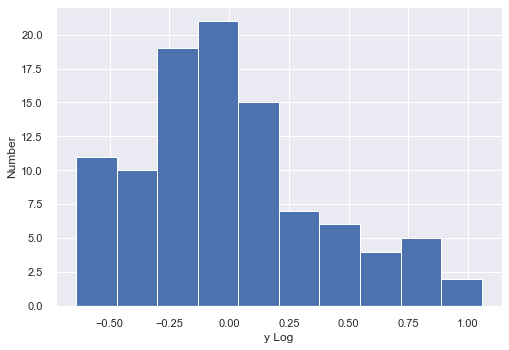

In [71]:
# Plot the residual distribution to look for a normal distribution.

my_lr4.plot_residual_histogram('y_log_residual', 'y Log')


### Interpreting the Residuals (errors)

The residuals show a mostly Normal distribution centred around 0, slightly skewed to the right.
The mean and median of the residuals are close to 0 so that is good.
The prediction error range is from -0.6 to 1.06 which seems pretty low. 

Overall, the analysis of the transformation residuals indicate that the transformation regression line is good.

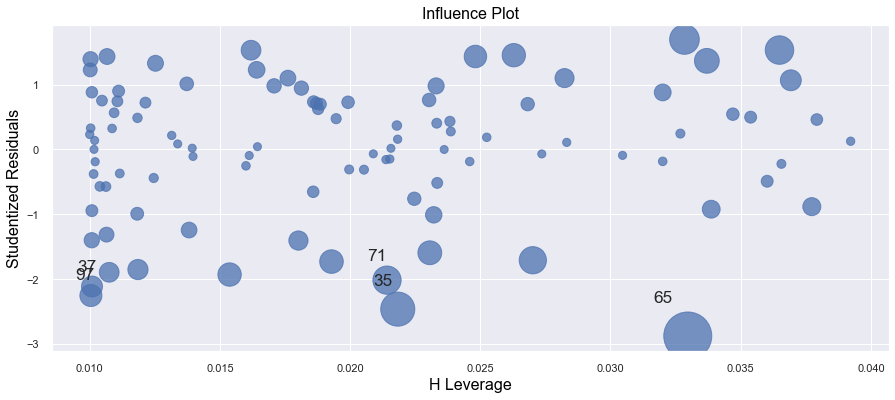

In [72]:
# Visualize the influence of the residuals.

my_lr4.visualize_residuals(results_transform_set4)


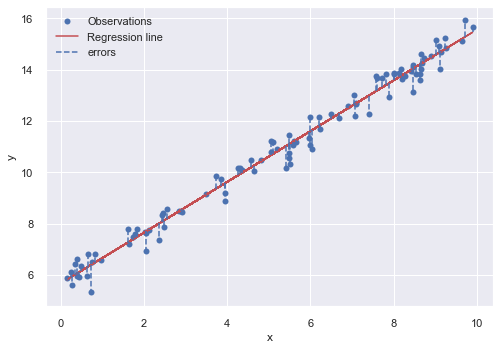

In [73]:
# From visualizing the residuals, we can see there is a point that is having a very large
# influence on the model.
#
# Visualize the regression line.

my_lr4.print_scatter_pred('x', 'y_log', 'y_log_pred', 'predicted vs actual')


In [74]:
# To see if there is any effect on the slope and intercept, remove a few of the points
# with the largest residual influence.

df4 = my_lr4.get_data_frame()

df4.drop([35,65,71,97], axis=0, inplace=True)
my_lr4.set_data_frame(df4)

# Re-fit the model.

results_transform_set4 = my_lr4.fit_model('x', 'y_log')
results_transform_set4.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  y_log   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     6805.
Date:                Sun, 26 Mar 2023   Prob (F-statistic):           1.70e-89
Time:                        22:52:32   Log-Likelihood:                -33.422
No. Observations:                  96   AIC:                             70.84
Df Residuals:                      94   BIC:                             75.97
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.7284      0.072     79.353      0.000       5.585       5.872
x              0.9849      0.012     82.495      0.000       0.961       1.009
==============================================================================
Omnibus:                        4.220   Durbin-Watson:                   2.326
Prob(Omnibus):                  0.121   Jarque-Bera (JB):                4.239
Skew:                          -0.488   Prob(JB):                        0.120
Kurtosis:                       2.674   Cond. No.                         12.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Interpreting the OLS Results After Removing Influential Residuals

After removing the top three influential residuals, it didn't appear to significantly affect the values.

The R-Squared value is slightly better (.986 vs .983)
 
The slope and intercepts are essentially the same (0.9849 vs 0.9898) and (5.7284 vs 5.6647)

count    9.600000e+01
mean     8.234154e-16
std      3.445371e-01
min     -6.250889e-01
25%     -2.495438e-01
50%     -2.899311e-02
75%      1.777388e-01
max      8.373246e-01
Name: y_log_residual, dtype: float64


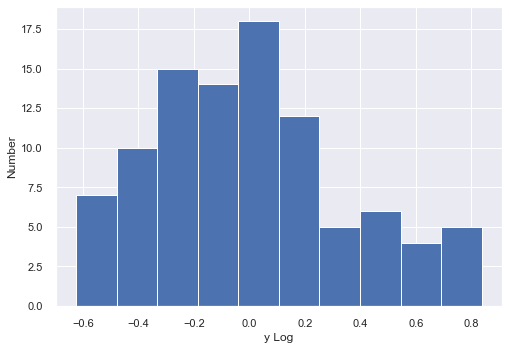

In [75]:
# Re-calculate the residuals.

my_lr4.calculate_residuals('x', 'y_log', 'y_log_pred', 'y_log_residual', results_transform_set4)
my_lr4.plot_residual_histogram('y_log_residual', 'y Log')


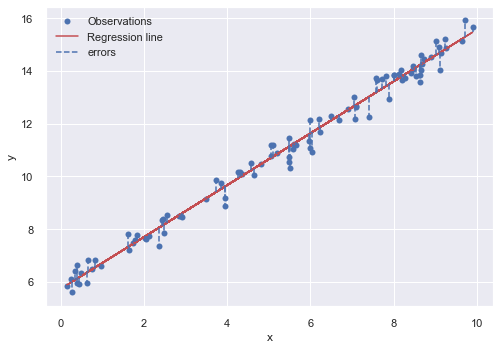

In [76]:
my_lr4.print_scatter_pred('x', 'y_log', 'y_log_pred', 'predicted vs actual')


### Interpreting the Residuals (errors) After Removing the Residuals with the Most Influence

The residuals show a mostly Normal distribution centred around 0.
The mean and the median of the residuals are close to 0 so that is good.
The prediction error range is from -0.625 to 0.837 which is better than the transformation before the influential residuals were removed. 

Overall, the analysis of the residuals, without the most influential points, indicate that the regression line is still good and comparable to the original.

### Equation

The transformed equation that creates a linear regression line:  log(y) = (0.9849 * x) + 5.7284
Therefore, transforming that back is: y = [(0.9849 * x) + 5.7284]^b

### Summary

The OLS regression line of the original data does not fit.  It therefore had to be transformed to get a linear regression model that would fit.  The transformation used was the log of Y.  After this transformation, and the removal of just a few influential residuals, the linear regression model fit quite well.

# <font color='Blue'>DATA SET 5</font>

In [77]:
# Create the Set 5 object and print out the Data Frame.

my_lr5 = linear_regression('Set 5', 'X', 'Y')
my_lr5.get_data_frame().head()


,Y,X
0,47.320319,9.0527
1,39.862491,7.3135
2,42.225779,8.6471
3,30.010689,5.8579
4,43.900459,7.9357


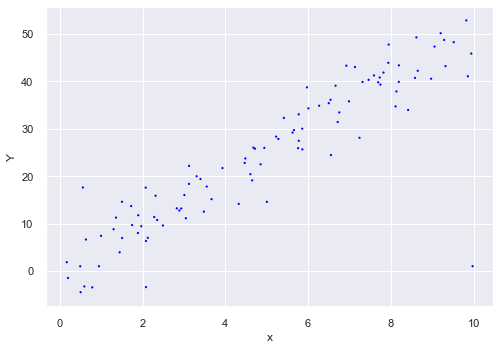

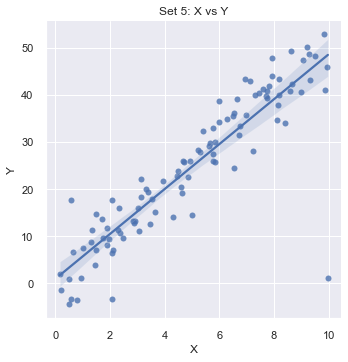

In [78]:
# Print the scatter matrix for the base X and Y variables

my_lr5.print_scatter('X', 'Y', 'Set 5: X vs Y')

In [79]:
# Visually, it looks linear.  Get the correlation.

my_lr5.get_corr('X', 'Y')


Correlation:            X         Y
X  1.000000  0.897892
Y  0.897892  1.000000


In [80]:
# There appears to be a strong correlation between x and y (.89).  No transformation needed.


In [81]:
# Validate the linear regression model by conducting an OLS fit.

results_set5 = my_lr5.fit_model('X', 'Y')
results_set5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.804
Method:                 Least Squares   F-statistic:                     411.9
Date:                Sun, 26 Mar 2023   Prob (F-statistic):           4.70e-37
Time:                        22:56:51   Log-Likelihood:                -334.42
No. Observations:                 101   AIC:                             672.8
Df Residuals:                      99   BIC:                             678.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9213      1.346      0.685      0.495      -1.749       3.591
X              4.7671      0.235     20.294      0.000       4.301       5.233
==============================================================================
Omnibus:                      113.783   Durbin-Watson:                   1.491
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2578.951
Skew:                          -3.591   Prob(JB):                         0.00
Kurtosis:                      26.691   Cond. No.                         11.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [82]:
# Extract the slope and intercept.

intercept, slope = my_lr5.get_regression_parameters(results_set5)

print ('Slope = ', slope, 'intercept = ', intercept)

# Identify the (x,y) point when x = 0.  Therefore, Y will just be the intercept.

print ('Therefore, a point on the graph (x,y) = (0,', intercept,')')


Slope =  4.767080844219761 intercept =  0.9212565388609862
Therefore, a point on the graph (x,y) = (0, 0.9212565388609862 )


In [83]:
# Get points from the data where x is near 0.

df5 = my_lr5.get_data_frame()
df5[df5['X'] < 1].head(3)


,Y,X
12,6.654544,0.6330
23,-3.222694,0.5947
43,-1.453000,0.2005


### Interpreting the OLS results.

The regression slope is positive (4.77) and the p-value is 0.  Therefore, there is a strong linear relationship.

The intercept point on the graph (x,y) = (0,.92) looks like it would be very close based on visually reviewing points around the intercept of the original data.

The R-squared value is quite high (.806) showing the regression model explains most of the data.

## Residuals


In [84]:
# Based on the slope and intercept, calculate the predictive Y results and the residuals.

my_lr5.calculate_residuals('X', 'Y', 'y_pred', 'y_residual', results_set5)
my_lr5.get_data_frame().head()


,Y,X,y_pred,y_residual
0,47.320319,9.0527,44.076209,-3.244110
1,39.862491,7.3135,35.785302,-4.077188
2,42.225779,8.6471,42.142681,-0.083097
3,30.010689,5.8579,28.846339,-1.164350
4,43.900459,7.9357,38.751380,-5.149079


count    1.010000e+02
mean     1.477366e-15
std      6.666383e+00
min     -1.403782e+01
25%     -3.542946e+00
50%     -1.164350e+00
75%      2.449717e+00
max      4.742030e+01
Name: y_residual, dtype: float64


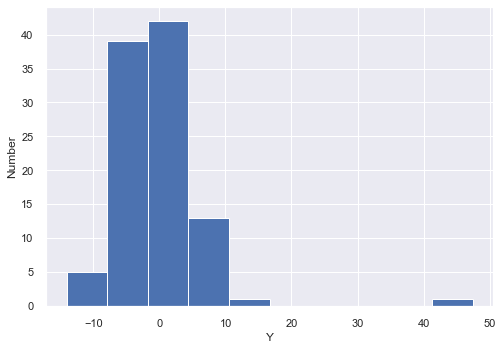

In [85]:
# Plot the residual distribution to look for a normal distribution.

my_lr5.plot_residual_histogram('y_residual', 'Y')


### Interpreting the Residuals (errors)

The residuals show a mostly Normal distribution centred around 0 but skewed right.  It would be better if it didn't have the outlier.
The mean and median of the residuals are close to 0 so that is good.
The prediction error range is from -14 to 47 which shows that there is an outlier. Otherwise, the maximum is around 18 which would show a better normal distribution.

Overall, the analysis of the residuals indicate that the regression line is good, except for that outlier.


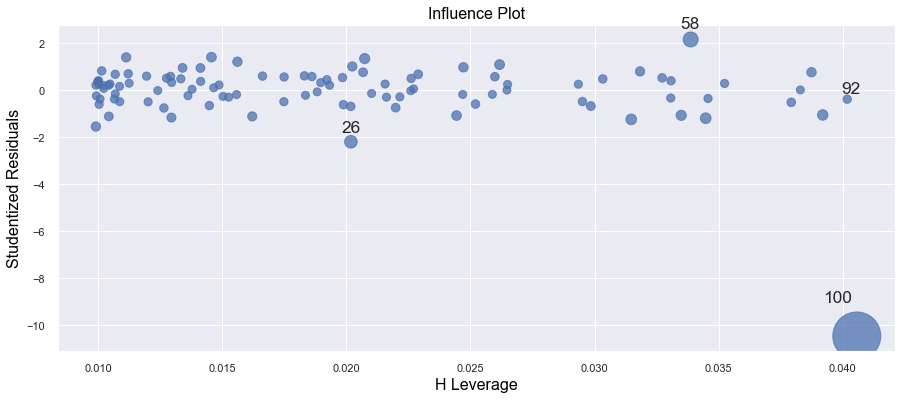

In [86]:
# Visualize the influence of the residuals.

my_lr5.visualize_residuals(results_set5)

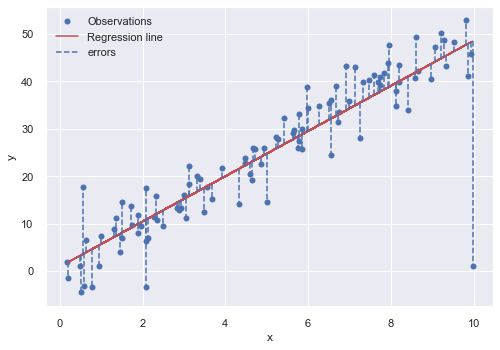

In [87]:
# From visualizing the residuals, we can see there is a point that is having a very large
# influence on the model.
#
# Visualize the regression line.

my_lr5.print_scatter_pred('X', 'Y', 'y_pred', 'predicted vs actual')

In [88]:
# To see if there is any effect on the slope and intercept, remove the outlier
# with the largest residual influence.

df5 = my_lr5.get_data_frame()

df5.drop([100], axis=0, inplace=True)
my_lr5.set_data_frame(df5)

# Re-fit the model.

results_set5 = my_lr5.fit_model('X', 'Y')
results_set5.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.906
Model:                            OLS   Adj. R-squared:                  0.905
Method:                 Least Squares   F-statistic:                     945.8
Date:                Sun, 26 Mar 2023   Prob (F-statistic):           3.84e-52
Time:                        22:58:58   Log-Likelihood:                -294.13
No. Observations:                 100   AIC:                             592.3
Df Residuals:                      98   BIC:                             597.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0993      0.935     -0.106      0.916      -1.954       1.756
X              5.0705      0.165     30.753      0.000       4.743       5.398
==============================================================================
Omnibus:                        3.022   Durbin-Watson:                   1.918
Prob(Omnibus):                  0.221   Jarque-Bera (JB):                2.760
Skew:                          -0.158   Prob(JB):                        0.252
Kurtosis:                       3.750   Cond. No.                         11.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Interpreting the OLS Results After Removing Influential Residuals

After removing the top influential residuals, it appeared to significantly affect the values.

The R-Squared value is better (.906 vs .806)
 
The slope and intercepts are essentially the same (5.07 vs 4.76) and (-.099 vs .92) which is good showing that it didn't really impact the regression line.

count    1.000000e+02
mean     2.495781e-15
std      4.605988e+00
min     -1.488861e+01
25%     -2.700744e+00
50%     -6.205125e-01
75%      2.993591e+00
max      1.384320e+01
Name: y_residual, dtype: float64


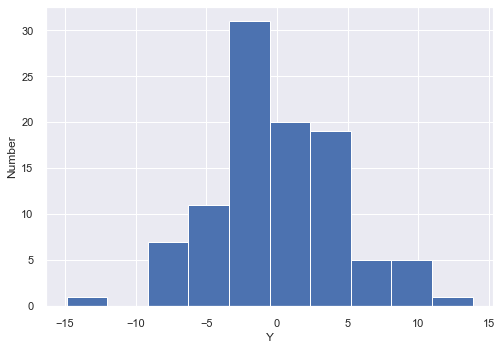

In [89]:
# Re-calculate the residuals.

my_lr5.calculate_residuals('X', 'Y', 'y_pred', 'y_residual', results_set5)
my_lr5.plot_residual_histogram('y_residual', 'Y')


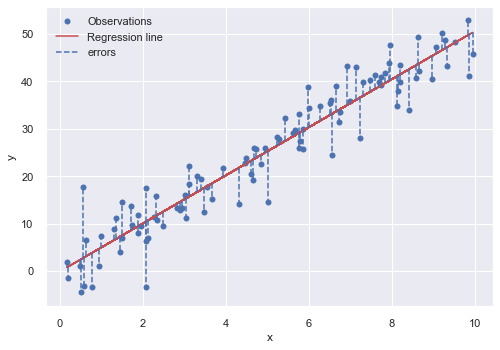

In [90]:
my_lr5.print_scatter_pred('X', 'Y', 'y_pred', 'predicted vs actual')


### Interpreting the Residuals (errors) After Removing the Residuals with the Most Influence

The residuals show a mostly Normal distribution centred around 0.
The mean and median of the residuals are close to 0 so that is good.
The prediction error range is from -14 to 14 which seems pretty good and is evenly balanced. 

Overall, the analysis of the residuals, without the most influential points, indicate that the regression line is still good and comparable to the original.

### Summary

The OLS regression line fits very well and removing only one influential residual had no significant impact on the regression line but the error distribution was better.

# <font color='Blue'>DATA SET 6</font> 

In [91]:
# Create the Set 6 object and print out the Data Frame.

my_lr6 = linear_regression('Set 6', 'x', 'y')
my_lr6.get_data_frame().head()


,y,x
0,-2.764835,1.1290
1,61.065734,6.9100
2,52.854588,7.8374
3,-2.881062,0.1335
4,59.045448,9.2425


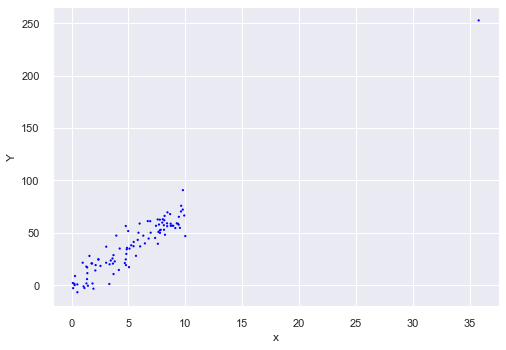

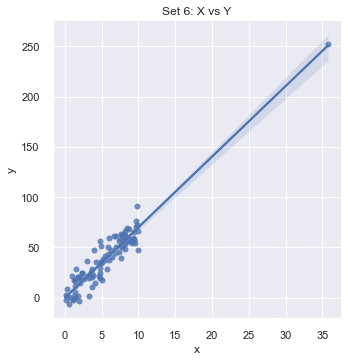

In [92]:
# Print the scatter matrix for the base X and Y variables

my_lr6.print_scatter('x', 'y', 'Set 6: X vs Y')


In [93]:
# Visually, it looks linear.  Get the correlation.

my_lr6.get_corr('x', 'y')


Correlation:            x         y
x  1.000000  0.955578
y  0.955578  1.000000


In [94]:
# There appears to be a strong correlation between x and y (.96).  No transformation needed.


In [95]:
# Validate the linear regression model by conducting an OLS fit.

results_set6 = my_lr6.fit_model('x', 'y')
results_set6.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                     1041.
Date:                Sun, 26 Mar 2023   Prob (F-statistic):           2.49e-54
Time:                        23:11:29   Log-Likelihood:                -367.52
No. Observations:                 101   AIC:                             739.0
Df Residuals:                      99   BIC:                             744.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.3059      1.534     -0.199      0.842      -3.350       2.739
x              7.0272      0.218     32.259      0.000       6.595       7.459
==============================================================================
Omnibus:                        0.494   Durbin-Watson:                   2.255
Prob(Omnibus):                  0.781   Jarque-Bera (JB):                0.262
Skew:                           0.120   Prob(JB):                        0.877
Kurtosis:                       3.070   Cond. No.                         11.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [96]:
# Extract the slope and intercept.

intercept, slope = my_lr6.get_regression_parameters(results_set6)

print ('Slope = ', slope, 'intercept = ', intercept)

# Identify the (x,y) point when x = 0.  Therefore, Y will just be the intercept.

print ('Therefore, a point on the graph (x,y) = (0,', intercept,')')


Slope =  7.027216147378344 intercept =  -0.3059107436463311
Therefore, a point on the graph (x,y) = (0, -0.3059107436463311 )


In [97]:
# Get points from the data where x is near 0.

df6 = my_lr6.get_data_frame()
df6[df6['x'] < 1].head(3)


,y,x
3,-2.881062,0.1335
45,-6.757358,0.5072
68,1.259964,0.2425


### Interpreting the OLS results.

The regression slope is positive (7.03) and the p-value is 0.  Therefore, there is a strong linear relationship.

The intercept point on the graph (x,y) = (0,-.31) looks like it would be correct based on visually reviewing points around the intercept of the original data.

The R-squared value is very high (.913) showing the regression model explains most of the data.


## Residuals


In [98]:
# Based on the slope and intercept, calculate the predictive Y results and the residuals.

my_lr6.calculate_residuals('x', 'y', 'y_pred', 'y_residual', results_set6)
my_lr6.get_data_frame().head()


,y,x,y_pred,y_residual
0,-2.764835,1.1290,7.627816,10.392652
1,61.065734,6.9100,48.252153,-12.813581
2,52.854588,7.8374,54.769193,1.914605
3,-2.881062,0.1335,0.632223,3.513284
4,59.045448,9.2425,64.643134,5.597687


count    1.010000e+02
mean    -1.341941e-14
std      9.252081e+00
min     -2.329843e+01
25%     -5.543791e+00
50%      3.559015e-01
75%      5.103361e+00
max      2.305339e+01
Name: y_residual, dtype: float64


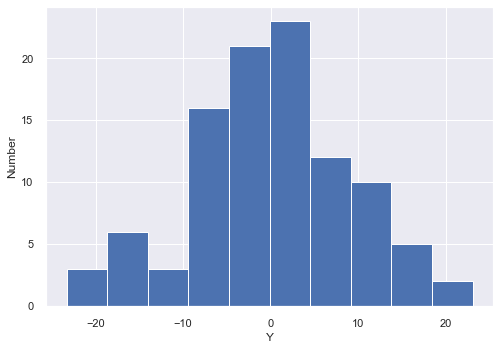

In [99]:
# Plot the residual distribution to look for a normal distribution.

my_lr6.plot_residual_histogram('y_residual', 'Y')


### Interpreting the Residuals (errors)

The residuals show a mostly Normal distribution centred around 0.
The mean and median of the residuals are close to 0 so that is good.
The prediction error range is from -23 to 23 which seems pretty good and is evenly balanced. 

Overall, the analysis of the residuals indicate that the regression line is good.


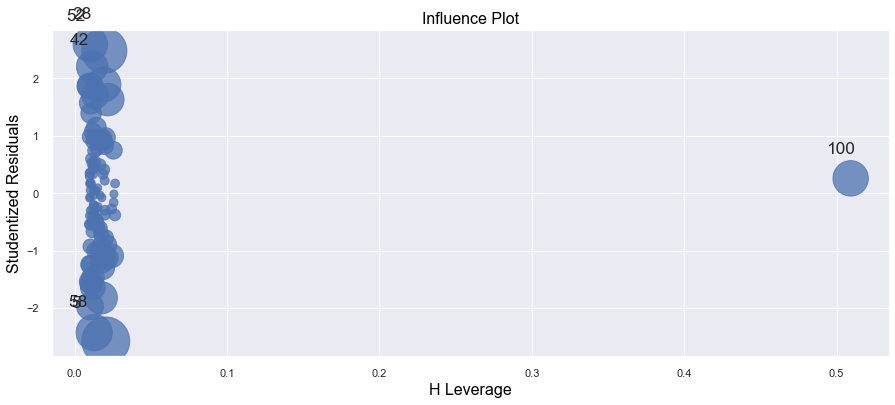

In [100]:
# Visualize the influence of the residuals.

my_lr6.visualize_residuals(results_set6)


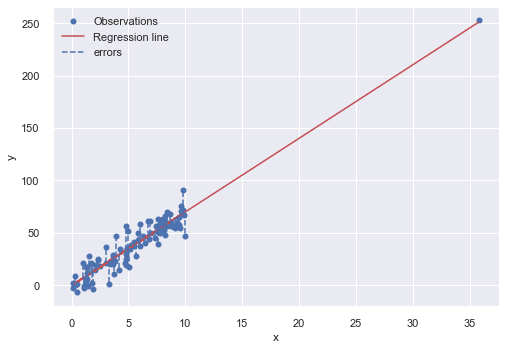

In [101]:
# From visualizing the residuals, we can see there is a point that is having a very large
# influence on the model.
#
# Visualize the regression line.

my_lr6.print_scatter_pred('x', 'y', 'y_pred', 'predicted vs actual')


In [102]:
# To see if there is any effect on the slope and intercept, remove a few of the points
# with the largest residual influence.

df6 = my_lr6.get_data_frame()

df6.drop([100], axis=0, inplace=True)
my_lr6.set_data_frame(df6)

# Re-fit the model.

results_set6 = my_lr6.fit_model('x', 'y')
results_set6.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     502.7
Date:                Sun, 26 Mar 2023   Prob (F-statistic):           2.29e-40
Time:                        23:12:51   Log-Likelihood:                -364.34
No. Observations:                 100   AIC:                             732.7
Df Residuals:                      98   BIC:                             737.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0203      1.899     -0.011      0.991      -3.788       3.748
x              6.9703      0.311     22.420      0.000       6.353       7.587
==============================================================================
Omnibus:                        0.459   Durbin-Watson:                   2.259
Prob(Omnibus):                  0.795   Jarque-Bera (JB):                0.261
Skew:                           0.123   Prob(JB):                        0.877
Kurtosis:                       3.044   Cond. No.                         12.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Interpreting the OLS Results After Removing Influential Residuals

After removing the top influential residual, it didn't appear to significantly affect the values.

The R-Squared value drops but is still quite good (.837 vs .913)
 
The slope and intercepts are essentially the same (6.97 vs 7.02) and (-.02 vs -.31)

count    1.000000e+02
mean    -7.460699e-16
std      9.295544e+00
min     -2.328386e+01
25%     -5.775247e+00
50%      4.739004e-01
75%      5.106210e+00
max      2.277057e+01
Name: y_residual, dtype: float64


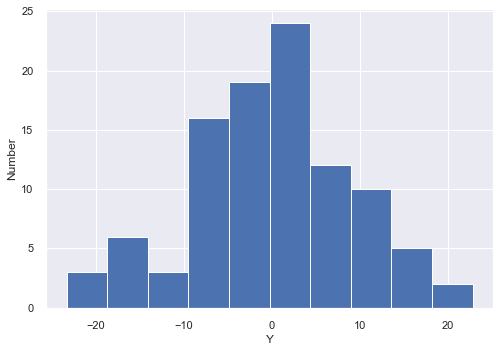

In [103]:
# Re-calculate the residuals.

my_lr6.calculate_residuals('x', 'y', 'y_pred', 'y_residual', results_set6)
my_lr6.plot_residual_histogram('y_residual', 'Y')


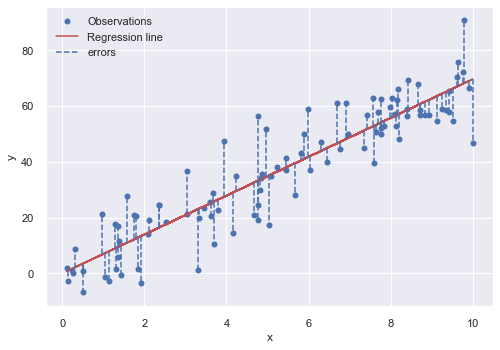

In [104]:
my_lr6.print_scatter_pred('x', 'y', 'y_pred', 'predicted vs actual')


### Interpreting the Residuals (errors) After Removing the Residuals with the Most Influence

The residuals show a mostly Normal distribution centred around 0.
The mean and median of the residuals are close to 0 so that is good.
The prediction error range is from -23 to 23 which is the same. 

Overall, the analysis of the residuals, without the most influential points, indicate that the regression line is still good and comparable to the original.

### Summary

The OLS regression line fits very well and removing the influential residuals has no significant impact on the data.